# VISEM-Tracking — descarga, EDA y preparación para YOLO

Este notebook está pensado para correr en **Kaggle Notebook**.

Antes de ejecutar:
1. En Kaggle, abre el panel derecho.
2. Ve a **Settings**.
3. Activa **Internet = On**.
4. Si vas a entrenar YOLO, activa **Accelerator = GPU T4**.

El dataset se descarga directamente desde Zenodo, por lo que **no necesitas agregarlo como Kaggle Input**.

## 1. Instalación e imports

Primero instalamos las librerías mínimas necesarias.

In [1]:
!pip -q install ultralytics scikit-learn opencv-python tqdm pandas matplotlib pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import os
import shutil
import random
import zipfile
import subprocess
import yaml

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

## 2. Configuración

El dataset oficial pesa aproximadamente **6.3 GB**, así que la descarga puede tardar.

In [3]:
# Carpeta de trabajo en Kaggle
WORK_DIR = Path("/kaggle/working")

# Archivo ZIP descargado desde Zenodo
ZIP_PATH = WORK_DIR / "VISEM-Tracking.zip"

# Carpeta donde se descomprime el dataset
EXTRACT_DIR = WORK_DIR / "VISEM-Tracking"

# URL oficial de descarga desde Zenodo
ZENODO_URL = "https://zenodo.org/records/7293726/files/VISEM-Tracking.zip?download=1"

# Clases oficiales del dataset
CLASS_NAMES = {
    0: "sperm",
    1: "cluster",
    2: "small_or_pinhead"
}

print("WORK_DIR:", WORK_DIR)
print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)

WORK_DIR: /kaggle/working
ZIP_PATH: /kaggle/working/VISEM-Tracking.zip
EXTRACT_DIR: /kaggle/working/VISEM-Tracking


In [4]:
import subprocess

if ZIP_PATH.exists():
    print(f"El ZIP ya existe: {ZIP_PATH}")
    print(f"Tamaño actual: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")
else:
    print("Descargando VISEM-Tracking... (Silencio total para evitar lag)")
    cmd = [
        "wget",
        "-q",             # Modo quiet
        "-c",             # Continuar descarga
        "-O", str(ZIP_PATH),
        ZENODO_URL
    ]
    
    # stdout=subprocess.DEVNULL envía cualquier texto al "agujero negro" del sistema
    # stderr=subprocess.STDOUT asegura que incluso los errores no saturen el buffer
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)

print("¡Descarga finalizada con éxito!")
print(f"Tamaño ZIP: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")

Descargando VISEM-Tracking... (Silencio total para evitar lag)
¡Descarga finalizada con éxito!
Tamaño ZIP: 5.88 GB


## 4. Descomprimir el dataset

Solo se descomprime si la carpeta todavía no existe.

In [5]:
if EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir()):
    print(f"El dataset ya está descomprimido en: {EXTRACT_DIR}")
else:
    print("Descomprimiendo dataset...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Descompresión finalizada.")

print("Contenido principal:")
for item in sorted(EXTRACT_DIR.iterdir())[:30]:
    print("-", item.name)

Descomprimiendo dataset...
Descompresión finalizada.
Contenido principal:
- VISEM_Tracking_Train_v4
- fatty_acids_serum_Train.csv
- fatty_acids_spermatoza_Train.csv
- participant_related_data_Train.csv
- semen_analysis_data_Train.csv
- sex_hormones_Train.csv
- sperm_counts_per_frame.csv
- visem-extracted-30s-excluding-selected-20
- visem-extracted-30s-selected-20-videos-excluding-first-30s


## 5. Inspeccionar estructura real de carpetas

Esto nos ayuda a confirmar dónde quedaron las imágenes y labels.

In [6]:
def show_tree(root: Path, max_depth=3, max_items_per_level=20):
    root = Path(root)
    base_depth = len(root.parts)

    for current_root, dirs, files in os.walk(root):
        current = Path(current_root)
        depth = len(current.parts) - base_depth

        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}{current.name}/")

        for f in files[:max_items_per_level]:
            print(f"{indent}  {f}")

        if len(files) > max_items_per_level:
            print(f"{indent}  ... {len(files) - max_items_per_level} archivos más")

show_tree(EXTRACT_DIR, max_depth=3)

VISEM-Tracking/
  participant_related_data_Train.csv
  sperm_counts_per_frame.csv
  semen_analysis_data_Train.csv
  sex_hormones_Train.csv
  fatty_acids_spermatoza_Train.csv
  fatty_acids_serum_Train.csv
  VISEM_Tracking_Train_v4/
    Train/
      35/
        35.mp4
        35.txt
      13/
        13.mp4
        13.txt
      30/
        30.mp4
        30.txt
      15/
        15.mp4
        15.txt
      23/
        23.mp4
        23.txt
      54/
        54.txt
        54.mp4
      60/
        60.txt
        60.mp4
      21/
        21.mp4
        21.txt
      14/
        14.txt
        14.mp4
      52/
        52.mp4
        52.txt
      36/
        36.mp4
        36.txt
      19/
        19.txt
        19.mp4
      12/
        12.txt
        12.mp4
      29/
        29.mp4
        29.txt
      38/
        38.mp4
        38.txt
      11/
        11.txt
        11.mp4
      24/
        24.txt
        24.mp4
      82/
        82.txt
        82.mp4
      47/
        47.txt
        47.mp

## 6. Buscar imágenes y labels YOLO

El dataset debe tener imágenes/frames y archivos `.txt` con anotaciones YOLO.

In [7]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
LABEL_EXTS = {".txt"}

all_images = sorted([p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
all_txts = sorted([p for p in EXTRACT_DIR.rglob("*.txt")])

print("Total imágenes encontradas:", len(all_images))
print("Total archivos .txt encontrados:", len(all_txts))

print("\nPrimeras imágenes:")
for p in all_images[:5]:
    print(p)

print("\nPrimeros .txt:")
for p in all_txts[:5]:
    print(p)

Total imágenes encontradas: 29370
Total archivos .txt encontrados: 58412

Primeras imágenes:
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_0.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_10.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_100.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1000.jpg

Primeros .txt:
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_0.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_1.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_10.txt
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/labels/11_frame_100.txt


## 7. Asociar cada imagen con su label

Buscamos el `.txt` correspondiente a cada imagen. Normalmente tienen el mismo nombre base.

In [8]:
def find_label_for_image(img_path: Path, all_label_paths):
    # Caso 1: label en la misma carpeta
    direct = img_path.with_suffix(".txt")
    if direct.exists():
        return direct

    # Caso 2: estructura tipo images/... y labels/...
    parts = list(img_path.parts)
    if "images" in parts:
        idx = parts.index("images")
        alt_parts = parts.copy()
        alt_parts[idx] = "labels"
        alt = Path(*alt_parts).with_suffix(".txt")
        if alt.exists():
            return alt

    # Caso 3: buscar por mismo stem dentro del dataset
    candidates = [p for p in all_label_paths if p.stem == img_path.stem]
    if len(candidates) == 1:
        return candidates[0]

    # Caso 4: si hay varios candidatos, elegir el que comparta más ruta con la imagen
    if len(candidates) > 1:
        img_parts = set(img_path.parts)
        candidates = sorted(
            candidates,
            key=lambda p: len(img_parts.intersection(set(p.parts))),
            reverse=True
        )
        return candidates[0]

    return None


records = []
for img in tqdm(all_images, desc="Asociando imágenes y labels"):
    label = find_label_for_image(img, all_txts)
    if label is None:
        continue

    # video_id: usamos la primera carpeta dentro de EXTRACT_DIR para evitar mezclar frames del mismo video
    rel_parts = img.relative_to(EXTRACT_DIR).parts
    video_id = rel_parts[0] if len(rel_parts) > 1 else img.parent.name

    records.append({
        "image_path": str(img),
        "label_path": str(label),
        "video_id": video_id,
        "image_name": img.name
    })

df = pd.DataFrame(records)
print("Pares imagen-label encontrados:", len(df))
df.head()

Asociando imágenes y labels:   0%|          | 0/29370 [00:00<?, ?it/s]

Pares imagen-label encontrados: 29196


,image_path,label_path,video_id,image_name
0,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg
1,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_1.jpg
2,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_10.jpg
3,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_100.jpg
4,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_1000.jpg


Si `df` sale vacío, detente aquí y revisa la estructura impresa arriba.  
Pero si aparecen pares imagen-label, puedes continuar.

In [9]:
if df.empty:
    raise RuntimeError("No se encontraron pares imagen-label. Revisa la estructura del dataset.")
else:
    print(df["video_id"].value_counts().head(20))

video_id
VISEM_Tracking_Train_v4    29196
Name: count, dtype: int64


## 8. Leer anotaciones YOLO

Formato esperado por línea:

```text
class_id x_center y_center width height
```

Todos los valores de la caja están normalizados entre 0 y 1.

In [10]:
def read_yolo_label(label_path):
    rows = []
    label_path = Path(label_path)

    if not label_path.exists():
        return rows

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            try:
                class_id = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:5])
            except ValueError:
                continue

            rows.append({
                "class_id": class_id,
                "x_center": x,
                "y_center": y,
                "width": w,
                "height": h,
                "area": w * h
            })

    return rows


ann_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Leyendo labels"):
    anns = read_yolo_label(row["label_path"])
    for ann in anns:
        ann_rows.append({
            **ann,
            "image_path": row["image_path"],
            "label_path": row["label_path"],
            "video_id": row["video_id"],
            "image_name": row["image_name"]
        })

ann_df = pd.DataFrame(ann_rows)

print("Total anotaciones:", len(ann_df))
ann_df.head()

Leyendo labels:   0%|          | 0/29196 [00:00<?, ?it/s]

Total anotaciones: 656335


,class_id,x_center,y_center,width,height,area,image_path,label_path,video_id,image_name
0,0,0.275781,0.412500,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg
1,0,0.238281,0.583333,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg
2,0,0.246094,0.847917,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg
3,0,0.194531,0.845833,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg
4,0,0.083594,0.806250,0.026562,0.0375,0.000996,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,/kaggle/working/VISEM-Tracking/VISEM_Tracking_...,VISEM_Tracking_Train_v4,11_frame_0.jpg


## 9. EDA básica

Estas gráficas ya sirven para la propuesta del proyecto.

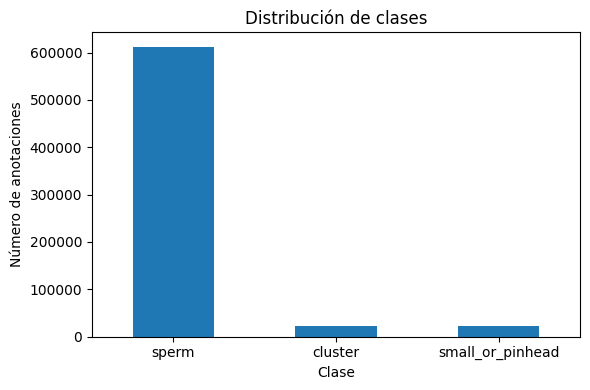

sperm               612377
cluster              21846
small_or_pinhead     22112
Name: count, dtype: int64

In [11]:
class_counts = ann_df["class_id"].value_counts().sort_index()
class_counts.index = [CLASS_NAMES.get(i, str(i)) for i in class_counts.index]

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de anotaciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

class_counts

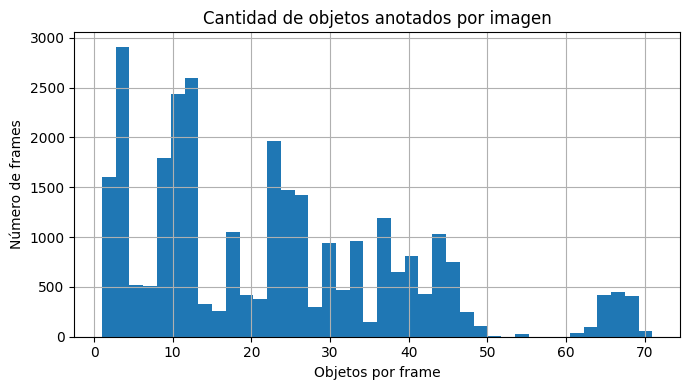

count    29196.000000
mean        22.480306
std         16.604505
min          1.000000
25%          9.000000
50%         21.000000
75%         34.000000
max         71.000000
dtype: float64

In [12]:
boxes_per_image = ann_df.groupby("image_path").size()

plt.figure(figsize=(7, 4))
boxes_per_image.hist(bins=40)
plt.title("Cantidad de objetos anotados por imagen")
plt.xlabel("Objetos por frame")
plt.ylabel("Número de frames")
plt.tight_layout()
plt.show()

boxes_per_image.describe()

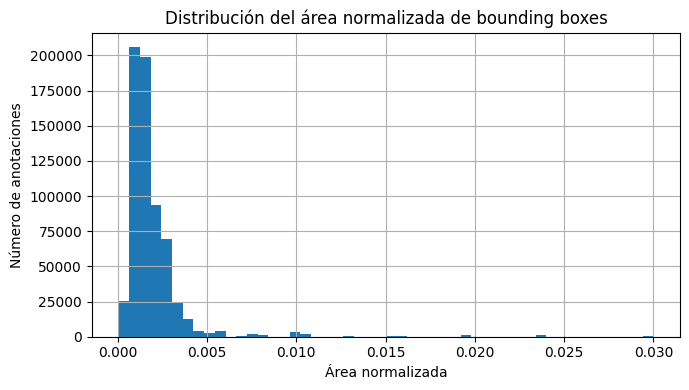

count    656335.000000
mean          0.001959
std           0.002085
min           0.000052
25%           0.001088
50%           0.001504
75%           0.002187
max           0.029997
Name: area, dtype: float64

In [13]:
plt.figure(figsize=(7, 4))
ann_df["area"].hist(bins=50)
plt.title("Distribución del área normalizada de bounding boxes")
plt.xlabel("Área normalizada")
plt.ylabel("Número de anotaciones")
plt.tight_layout()
plt.show()

ann_df["area"].describe()

## 10. Visualizar ejemplos con bounding boxes

Esto confirma visualmente que las anotaciones se están leyendo bien.

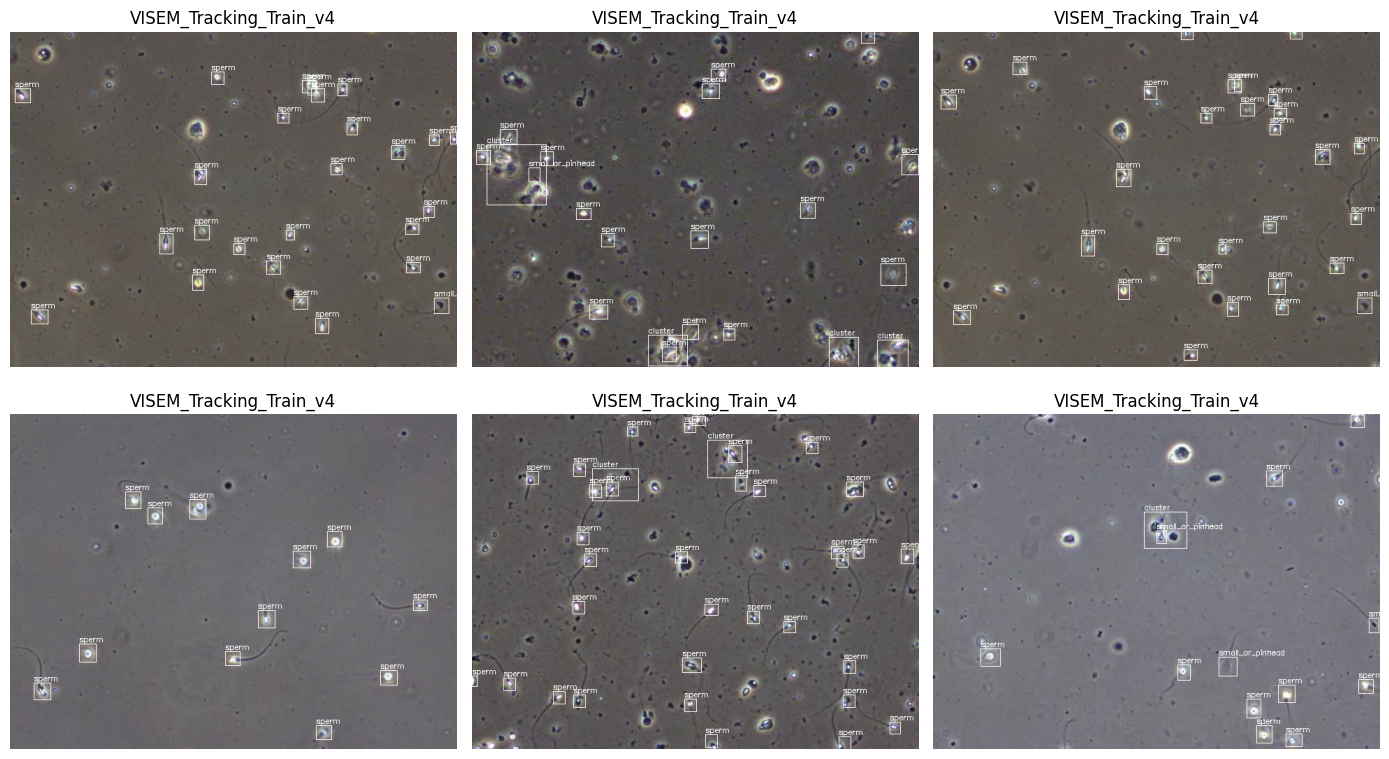

In [14]:
def draw_yolo_boxes(image_path, label_path, class_names):
    image_path = Path(image_path)
    label_path = Path(label_path)

    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for ann in read_yolo_label(label_path):
        cls = ann["class_id"]
        x_center = ann["x_center"] * w
        y_center = ann["y_center"] * h
        bw = ann["width"] * w
        bh = ann["height"] * h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), 1)
        cv2.putText(
            img,
            class_names.get(cls, str(cls)),
            (x1, max(0, y1 - 3)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 255),
            1
        )

    return img


sample_df = df.sample(min(6, len(df)), random_state=42)

plt.figure(figsize=(14, 8))
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    img = draw_yolo_boxes(row["image_path"], row["label_path"], CLASS_NAMES)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(row["video_id"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Split por video

Esto es muy importante: **no dividimos por frame**, porque frames del mismo video son muy parecidos.  
Dividimos por `video_id` para evitar fuga de información.

In [15]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import re

# Primero miramos ejemplos de rutas reales
print("Ejemplos de image_path:")
for p in df["image_path"].drop_duplicates().head(10):
    print(p)

def infer_video_id(image_path):
    """
    Intenta inferir el video_id desde:
    1. El nombre del archivo.
    2. La carpeta padre real.
    """
    p = Path(image_path)
    stem = p.stem

    # Caso común: nombres tipo 1_xxx, 01_xxx, video1_xxx
    match = re.match(r"([A-Za-z]*\d+)[_\-]", stem)
    if match:
        return match.group(1)

    # Si no funciona, usa la carpeta padre
    ignored = {
        "images", "labels", "train", "val", "valid", "validation", "test",
        "VISEM_Tracking_Train_v4", "visem_tracking"
    }

    for part in reversed(p.parts[:-1]):
        if part not in ignored:
            return part

    return stem

df["video_id"] = df["image_path"].apply(infer_video_id)

video_ids = sorted(df["video_id"].unique())

print("\nVideos detectados:", len(video_ids))
print(video_ids[:30])

# Split correcto por video si hay suficientes videos detectados
if len(video_ids) >= 3:
    train_videos, temp_videos = train_test_split(
        video_ids,
        test_size=0.30,
        random_state=42
    )

    val_videos, test_videos = train_test_split(
        temp_videos,
        test_size=0.50,
        random_state=42
    )

    df["split"] = "train"
    df.loc[df["video_id"].isin(val_videos), "split"] = "val"
    df.loc[df["video_id"].isin(test_videos), "split"] = "test"

else:
    print("Solo se detectó 1 video_id. Se hará split por imágenes como fallback temporal.")
    print("Ojo: esto NO es lo ideal para el reporte final porque puede causar leakage.")

    train_idx, temp_idx = train_test_split(
        df.index,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    df["split"] = "train"
    df.loc[val_idx, "split"] = "val"
    df.loc[test_idx, "split"] = "test"

print("\nDistribución final:")
print(df["split"].value_counts())

Ejemplos de image_path:
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_0.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_10.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_100.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1000.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1001.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1002.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1003.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1004.jpg
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/images/11_frame_1005.jpg

Videos detectados: 20
['11', '12', '13', '14', '15', '19', '21', '22', '23', '24', '29', '30',

In [16]:
split_summary = df.groupby(["split", "video_id"]).size().reset_index(name="num_frames")
split_summary.head(20)

,split,video_id,num_frames
0,test,11,1470
1,test,19,1470
2,test,54,1470
3,train,13,1470
4,train,14,1470
5,train,15,1470
6,train,21,1470
7,train,22,1470
8,train,24,1470
9,train,29,1470


## 12. Crear dataset en formato YOLO

Se crean carpetas:

```text
/kaggle/working/yolo_visem/
  images/train
  images/val
  images/test
  labels/train
  labels/val
  labels/test
```

In [17]:
YOLO_DIR = WORK_DIR / "yolo_visem"

for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

def safe_copy(src, dst):
    src = Path(src)
    dst = Path(dst)
    if not dst.exists():
        shutil.copy2(src, dst)

for _, row in tqdm(df.iterrows(), total=len(df), desc="Copiando a formato YOLO"):
    split = row["split"]
    img_src = Path(row["image_path"])
    lbl_src = Path(row["label_path"])

    # Evitar colisiones de nombres usando video_id como prefijo
    new_stem = f"{row['video_id']}__{img_src.stem}"

    img_dst = YOLO_DIR / "images" / split / f"{new_stem}{img_src.suffix.lower()}"
    lbl_dst = YOLO_DIR / "labels" / split / f"{new_stem}.txt"

    safe_copy(img_src, img_dst)
    safe_copy(lbl_src, lbl_dst)

print("Dataset YOLO creado en:", YOLO_DIR)

for split in ["train", "val", "test"]:
    n_imgs = len(list((YOLO_DIR / "images" / split).glob("*")))
    n_lbls = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    print(split, "imágenes:", n_imgs, "labels:", n_lbls)

Copiando a formato YOLO:   0%|          | 0/29196 [00:00<?, ?it/s]

Dataset YOLO creado en: /kaggle/working/yolo_visem
train imágenes: 20550 labels: 20550
val imágenes: 4236 labels: 4236
test imágenes: 4410 labels: 4410


## 13. Crear archivo `data.yaml`

Este archivo le dice a YOLO dónde están las imágenes y cuáles son las clases.

In [18]:
data_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

YAML_PATH = YOLO_DIR / "data.yaml"

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(YAML_PATH)
print(YAML_PATH.read_text())

/kaggle/working/yolo_visem/data.yaml
path: /kaggle/working/yolo_visem
train: images/train
val: images/val
test: images/test
names:
  0: sperm
  1: cluster
  2: small_or_pinhead



## 14. Entrenar YOLO

Esta es la primera parte de Deep Learning real del proyecto: detección de espermatozoides.

Recomendación:
- Ejecutar con GPU.
- Empezar con `yolov8n.pt` porque es liviano.
- Si funciona bien, probar luego `yolov8s.pt`.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(YAML_PATH),
    epochs=30,
    imgsz=640,
    batch=16,
    patience=8,
    project=str(WORK_DIR / "runs"),
    name="visem_yolov8n",
    pretrained=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_visem/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

## 15. Evaluar en test

Después del entrenamiento, evaluamos sobre el split de test.

In [20]:
best_model_path = WORK_DIR / "runs" / "visem_yolov8n" / "weights" / "best.pt"
best_model = YOLO(str(best_model_path))

metrics = best_model.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=640
)

metrics

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1883.4±604.0 MB/s, size: 80.7 KB)
val: Scanning /kaggle/working/yolo_visem/labels/test... 4410 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4410/4410 1.2Kit/s 3.8s0.0s
val: New cache created: /kaggle/working/yolo_visem/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 276/276 7.6it/s 36.4s<0.1s
                   all       4410     131841      0.195      0.193       0.15     0.0419
                 sperm       4410     119137      0.561      0.578      0.429      0.117
               cluster       4297      11534     0.0247   0.000347      0.021    0.00834
      small_or_pinhead       1170       1170          0          0   1.95e-06   1.95e-07
Speed: 0.6ms preprocess, 2.7ms inference, 0.0ms loss

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d96d7e49df0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## 16. Probar predicciones visuales

Esto genera ejemplos de predicción sobre imágenes de test.

In [21]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*"))[:10]

pred_results = best_model.predict(
    source=[str(p) for p in test_images],
    imgsz=640,
    conf=0.25,
    save=True,
    project=str(WORK_DIR / "predictions"),
    name="test_examples"
)

print("Predicciones guardadas en:", WORK_DIR / "predictions" / "test_examples")


0: 480x640 49 sperms, 4.1ms
1: 480x640 49 sperms, 4.1ms
2: 480x640 49 sperms, 4.1ms
3: 480x640 50 sperms, 4.1ms
4: 480x640 46 sperms, 1 small_or_pinhead, 4.1ms
5: 480x640 46 sperms, 1 small_or_pinhead, 4.1ms
6: 480x640 47 sperms, 4.1ms
7: 480x640 46 sperms, 4.1ms
8: 480x640 46 sperms, 4.1ms
9: 480x640 45 sperms, 4.1ms
Speed: 1.1ms preprocess, 4.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/predictions/test_examples
Predicciones guardadas en: /kaggle/working/predictions/test_examples


## 17. Tracking sobre un video o secuencia

Este bloque es opcional. Sirve para la parte de tracking.

Si el dataset trae videos originales, puedes poner la ruta de un `.mp4` o `.avi`.  
Si no tienes video original, para la propuesta puedes dejar esta parte como siguiente fase.

In [22]:
# Buscar posibles videos dentro del dataset
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}
all_videos = sorted([p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in VIDEO_EXTS])

print("Videos encontrados:", len(all_videos))
for p in all_videos[:10]:
    print(p)

Videos encontrados: 522
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/12/12.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/13/13.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/14/14.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/15/15.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/19/19.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/21/21.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/22/22.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/23/23.mp4
/kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/24/24.mp4


In [23]:
if len(all_videos) > 0:
    video_path = all_videos[0]
    print("Usando video:", video_path)

    tracking_results = best_model.track(
        source=str(video_path),
        tracker="bytetrack.yaml",
        conf=0.25,
        imgsz=640,
        save=True,
        project=str(WORK_DIR / "tracking"),
        name="visem_tracking_example"
    )

    print("Resultado guardado en:", WORK_DIR / "tracking" / "visem_tracking_example")
else:
    print("No se encontraron videos originales. El dataset puede venir como frames + labels.")

Usando video: /kaggle/working/VISEM-Tracking/VISEM_Tracking_Train_v4/Train/11/11.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 135ms
Prepared 1 package in 30ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame

## 18. Qué entregar con este notebook

Para la propuesta puedes usar:

1. **Dataset:** VISEM-Tracking.
2. **Inputs:** frames/videos microscópicos.
3. **Labels:** bounding boxes YOLO con clases `sperm`, `cluster`, `small_or_pinhead`.
4. **Split:** por video, 70/15/15.
5. **Modelo:** YOLOv8 para detección.
6. **Validación:** precision, recall, mAP@50 y mAP@50:95.
7. **EDA:** distribución de clases, objetos por frame y ejemplos con bounding boxes.
8. **Siguiente fase:** tracking con ByteTrack y extracción de métricas de movimiento.